# Bankruptcy Prediction for U.S. Public Companies

## Overview

When a publicly listed company can no longer pay its debts, it can file for bankruptcy protection under U.S. law. This triggers a legal process that costs creditors, employees, and shareholders billions of dollars. Between 1999 and 2018, thousands of NYSE and NASDAQ companies - from small manufacturers to household names - went bankrupt. The question is: **can we predict which companies are about to fail, using only their financial ratios?**

This is not a new problem. Banks and hedge funds spend enormous resources on exactly this kind of analysis. But most of their models are proprietary. This project uses publicly available accounting data to build a transparent machine learning model. Predicting bankruptcy accurately matters in two directions: for **regulators and creditors** who want to catch every failing company (recall), and for **investors** who only want to act when they're confident (precision). We will explore both priorities explicitly.

In this project we work with accounting data for publicly listed companies on the New York Stock Exchange (NYSE) and NASDAQ from 1999 to 2018. Each row is one firm-year observation - a snapshot of a company's financial health in a given year. The target column, `Bankrupt`, is 1 if the company filed for Chapter 7 or Chapter 11 bankruptcy in the **following** fiscal year, and 0 otherwise.

The data comes as a compressed JSON file with a schema-plus-data structure. We load it with `gzip` and `json`, build a `wrangle` function that returns a tidy DataFrame, then address the extreme class imbalance (~97% non-bankrupt vs ~3% bankrupt) using random under- and over-sampling before building a progression of three classifiers: a baseline Decision Tree, a Random Forest with GridSearchCV, and a Gradient Boosting classifier. Model quality is judged primarily on **precision** and **recall** against the minority (bankrupt) class, not raw accuracy.

**Covered in this project:**
- CLI navigation and `gzip` decompression
- Loading nested JSON into a DataFrame
- Resampling imbalanced data (under-sample, over-sample)
- Confusion matrix interpretation for imbalanced problems
- `pickle` for model serialisation
- `classification_report` and threshold-based precision/recall trade-offs
- Random Forest with `GridSearchCV` and cross-validation
- Gradient Boosting classifier
- Saving a reusable prediction module (`my_predictor.py`)

**Dataset:** American Stock Market Bankruptcy Prediction  
**Source:** GitHub - `sowide/bankruptcy_dataset` (Pellegrino et al., 2022, *Future Internet*, MDPI)  
**DOI reference:** https://github.com/sowide/bankruptcy_dataset  
**License:** CC BY 4.0  
**Shape:** 78,682 firm-year observations, 18 financial ratio features + 1 target  
**Period:** 1999–2018, NYSE and NASDAQ listed companies

---
## 1: Loading JSON Data from the Command Line

The data file is `us-bankruptcy-data.json.gz` - a gzip-compressed JSON file. Before touching Python, let's confirm the file exists and inspect its structure from the terminal.

### 1.1 Explore the file from the terminal

Navigate to your project folder and run:

```bash
cd 'project/path'
ls data
```

You should see `us-bankruptcy-data.json.gz`. Now decompress it to inspect:

```bash
gzip -dkf data/us-bankruptcy-data.json.gz
```

Then peek at the first lines (or just read it in Python below).

In [1]:
# You can also decompress from inside the notebook:
# %%bash
# cd data
# gzip -dkf us-bankruptcy-data.json.gz
# ls

### 1.2 Imports

In [2]:
import gzip
import json
import pickle

import pandas as pd

### 1.3 Open the compressed file and load as a dictionary

In [3]:
with gzip.open("data/us-bankruptcy-data.json.gz", "r") as f:
    us_data = json.load(f)

print(type(us_data))
print(us_data.keys())

<class 'dict'>
dict_keys(['schema', 'metadata', 'data'])


The dictionary has three keys: `schema` (column names and types), `metadata` (source information), and `data` (the actual records).

In [4]:
# Inspect metadata
print(us_data["metadata"])

{'source': 'Pellegrino et al. (2022). Machine Learning for Bankruptcy Prediction in the American Stock Market: Dataset and Benchmarks. Future Internet, 14(8), 244.', 'repository': 'https://github.com/sowide/bankruptcy_dataset', 'license': 'CC BY 4.0', 'exchanges': 'NYSE and NASDAQ', 'period': '1999-2018'}


In [5]:
# Look at the schema - what columns do we have?
for field in us_data["schema"]["fields"]:
    print(field["name"], "-", field["type"])

company_id - integer
X1 - number
X2 - number
X3 - number
X4 - number
X5 - number
X6 - number
X7 - number
X8 - number
X9 - number
X10 - number
X11 - number
X12 - number
X13 - number
X14 - number
X15 - number
X16 - number
X17 - number
X18 - number
Division - number
MajorGroup - integer
Bankrupt - integer


In [6]:
# How many company-year observations are there?
print("Number of observations:", len(us_data["data"]))

Number of observations: 66880


In [7]:
# Inspect a single record
us_data["data"][0]

{'company_id': 1,
 'X1': 511267.0,
 'X2': 740998.0,
 'X3': 833107.0,
 'X4': 180447.0,
 'X5': 18373.0,
 'X6': 70658.0,
 'X7': 89031.0,
 'X8': 191226.0,
 'X9': 336.01800000000003,
 'X10': 163816.0,
 'X11': 35.163000000000004,
 'X12': 201026.0,
 'X13': 128.34799999999998,
 'X14': 1024333.0,
 'X15': 372.7519,
 'X16': 401483.0,
 'X17': 1024333.0,
 'X18': 935302.0,
 'Division': 'D',
 'MajorGroup': 37,
 'Bankrupt': 0}

In [8]:
# Confirm all records have the same number of features
expected = len(us_data["data"][0])
for record in us_data["data"]:
    if len(record) != expected:
        print("ALERT: record with different field count found!")
        break
else:
    print(f"All records have {expected} fields. ✓")

All records have 22 fields. ✓


### 1.4 Build the wrangle function

We'll wrap all loading logic into one function so that every subsequent section calls a single entry point.

In [9]:
def wrangle(filepath):
    """Load a gzip-compressed JSON file of US bankruptcy data into a tidy DataFrame.
    
    Parameters
    ----------
    filepath : str
        Path to the .json.gz file.
    
    Returns
    -------
    pd.DataFrame
        DataFrame indexed by company_id, one row per firm-year observation.
    """
    with gzip.open(filepath, "r") as f:
        data = json.load(f)
    
    df = pd.DataFrame.from_dict(data["data"]).set_index("company_id")
    return df


df = wrangle("data/us-bankruptcy-data.json.gz")
print("Shape:", df.shape)
df.head()

Shape: (66880, 21)


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X12,X13,X14,X15,X16,X17,X18,Division,MajorGroup,Bankrupt
company_id,,,,,,,,,,,,,,,,,,,,,
1,511267.0,740998.000,833107.0,180447.0,18373.00,70658.00,89031.0,191226.000,336.018,163816.0,...,201026.000,128.348,1024333.000,372.7519,401483.0,1024333.000,935302.0,D,37,0
2,485856.0,701.854,713811.0,179987.0,18577.00,45.79,64367.0,160444.000,320.590,125392.0,...,204065.000,115187.000,874255.000,377.1180,361642.0,874255.000,809888.0,D,37,0
3,436656.0,710199.000,526477.0,217699.0,22496.00,4711.00,27207.0,112244.000,286588.000,150464.0,...,139.603,77528.000,638721.000,364.5928,399964.0,638721.000,611514.0,D,37,0
4,396412.0,686.621,496747.0,164658.0,27172.00,3573.00,30745.0,109.590,259954.000,203575.0,...,124106.000,66322.000,606337.000,143.3295,391633.0,606337.000,575592.0,D,37,0
6,474542.0,732.230,598172.0,227159.0,27.95,33824.00,61774.0,149.676,255477.000,160025.0,...,142.450,127121.000,747.848,522.6794,417486.0,747.848,686074.0,D,37,0


---
>  The JSON format is the standard for semi-structured data on the web and in APIs. Unlike a flat CSV, a JSON file can carry metadata and schema definitions alongside the data itself - that's why our file has three keys. The `gzip` format saves roughly 80% of disk space, which matters for large datasets. The `wrangle` function is our single source of truth for data loading: every section starts by calling it, and if the data format changes, we only need to fix one place. For U.S. stock market data, this pattern is especially common because financial data vendors like Bloomberg and FactSet export in nested JSON.

## 2: Exploratory Data Analysis & Imbalanced Data

In [3]:
import gzip
import json
import pickle

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeClassifier

In [11]:
def wrangle(filepath):
    with gzip.open(filepath, "r") as f:
        data = json.load(f)
    df = pd.DataFrame.from_dict(data["data"]).set_index("company_id")
    return df


df = wrangle("data/us-bankruptcy-data.json.gz")
print("Shape:", df.shape)
df.head()

Shape: (66880, 21)


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X12,X13,X14,X15,X16,X17,X18,Division,MajorGroup,Bankrupt
company_id,,,,,,,,,,,,,,,,,,,,,
1,511267.0,740998.000,833107.0,180447.0,18373.00,70658.00,89031.0,191226.000,336.018,163816.0,...,201026.000,128.348,1024333.000,372.7519,401483.0,1024333.000,935302.0,D,37,0
2,485856.0,701.854,713811.0,179987.0,18577.00,45.79,64367.0,160444.000,320.590,125392.0,...,204065.000,115187.000,874255.000,377.1180,361642.0,874255.000,809888.0,D,37,0
3,436656.0,710199.000,526477.0,217699.0,22496.00,4711.00,27207.0,112244.000,286588.000,150464.0,...,139.603,77528.000,638721.000,364.5928,399964.0,638721.000,611514.0,D,37,0
4,396412.0,686.621,496747.0,164658.0,27172.00,3573.00,30745.0,109.590,259954.000,203575.0,...,124106.000,66322.000,606337.000,143.3295,391633.0,606337.000,575592.0,D,37,0
6,474542.0,732.230,598172.0,227159.0,27.95,33824.00,61774.0,149.676,255477.000,160025.0,...,142.450,127121.000,747.848,522.6794,417486.0,747.848,686074.0,D,37,0


### 2.1 Explore the DataFrame

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 66880 entries, 1 to 78682
Data columns (total 21 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   X1          66880 non-null  float64
 1   X2          66880 non-null  float64
 2   X3          66880 non-null  float64
 3   X4          66880 non-null  float64
 4   X5          66880 non-null  float64
 5   X6          66880 non-null  float64
 6   X7          66880 non-null  float64
 7   X8          66880 non-null  float64
 8   X9          66880 non-null  float64
 9   X10         66880 non-null  float64
 10  X11         66880 non-null  float64
 11  X12         66880 non-null  float64
 12  X13         66880 non-null  float64
 13  X14         66880 non-null  float64
 14  X15         66880 non-null  float64
 15  X16         66880 non-null  float64
 16  X17         66880 non-null  float64
 17  X18         66880 non-null  float64
 18  Division    66880 non-null  object 
 19  MajorGroup  66880 non-null  in

### 2.2 Class balance - visualising the imbalance

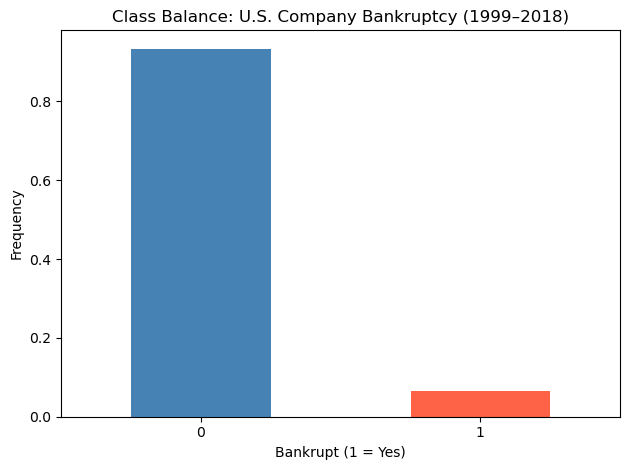

Non-bankrupt (majority): 0.9337
Bankrupt (minority):     0.0663


In [13]:
df["Bankrupt"].value_counts(normalize=True).plot(
    kind="bar",
    xlabel="Bankrupt (1 = Yes)",
    ylabel="Frequency",
    title="Class Balance: U.S. Company Bankruptcy (1999–2018)",
    color=["steelblue", "tomato"]
)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

majority_class_prop, minority_class_prop = df["Bankrupt"].value_counts(normalize=True)
print(f"Non-bankrupt (majority): {majority_class_prop:.4f}")
print(f"Bankrupt (minority):     {minority_class_prop:.4f}")

The dataset is severely imbalanced: roughly 93% of company-year observations are non-bankrupt. A naive model that always predicts "not bankrupt" would score ~93% accuracy - a meaningless metric here.

### 2.3 Explore a key financial ratio: Debt Ratio %

In [18]:
df = df.rename(columns={
    'X1': 'Current Assets',
    'X2': 'Cost of Goods Sold',
    'X3': 'Depreciation and Amortization',
    'X4': 'EBITDA',
    'X5': 'Inventory',
    'X6': 'Net Income',
    'X7': 'Total Receivables',
    'X8': 'Market Value',
    'X9': 'Net Sales',
    'X10': 'Total Assets',
    'X11': 'Total Long-term Debt',
    'X12': 'EBIT',
    'X13': 'Gross Profit',
    'X14': 'Total Current Liabilities',
    'X15': 'Retained Earnings',
    'X16': 'Total Revenue',
    'X17': 'Total Liabilities',
    'X18': 'Total Operating Expenses',
})

In [19]:
# Summary statistics for Debt Ratio %
df["Debt Ratio %"] = (df["Total Liabilities"] / df["Total Assets"]) * 100

print(df["Debt Ratio %"].describe().apply("{0:,.4f}".format))

count        66,880.0000
mean         71,175.0854
std         298,435.4440
min        -138,869.1873
25%             141.5964
50%             410.7156
75%             782.1879
max      45,260,000.0000
Name: Debt Ratio %, dtype: object


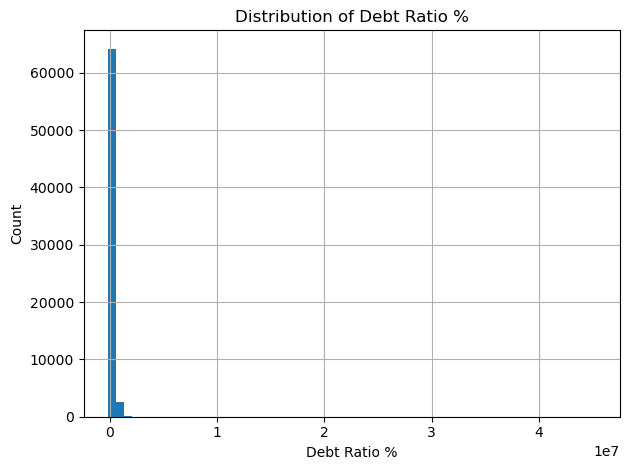

In [20]:
# The distribution is heavily skewed — median ≠ mean
df["Debt Ratio %"].hist(bins=60)
plt.xlabel("Debt Ratio %")
plt.ylabel("Count")
plt.title("Distribution of Debt Ratio %")
plt.tight_layout()
plt.show()

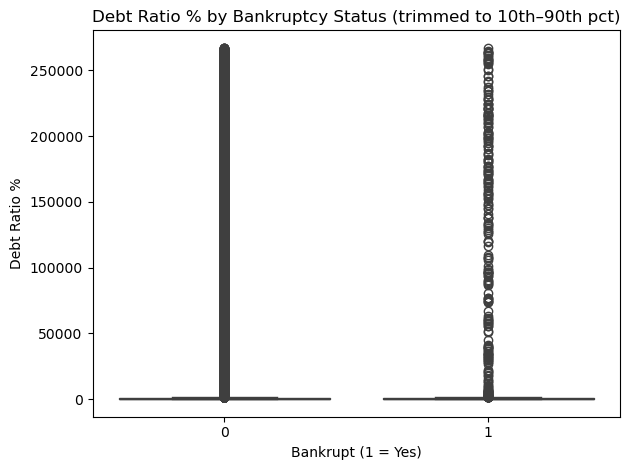

In [21]:
# Boxplot (trimmed to 10th–90th percentile to handle outliers)
q1, q9 = df["Debt Ratio %"].quantile([0.1, 0.9])
mask = df["Debt Ratio %"].between(q1, q9)

sns.boxplot(x="Bankrupt", y="Debt Ratio %", data=df[mask])
plt.xlabel("Bankrupt (1 = Yes)")
plt.ylabel("Debt Ratio %")
plt.title("Debt Ratio % by Bankruptcy Status (trimmed to 10th–90th pct)")
plt.tight_layout()
plt.show()

Bankrupt companies tend to exhibit slightly higher or more variable debt ratios, though the distributions overlap substantially.

### 2.4 Check for multicollinearity

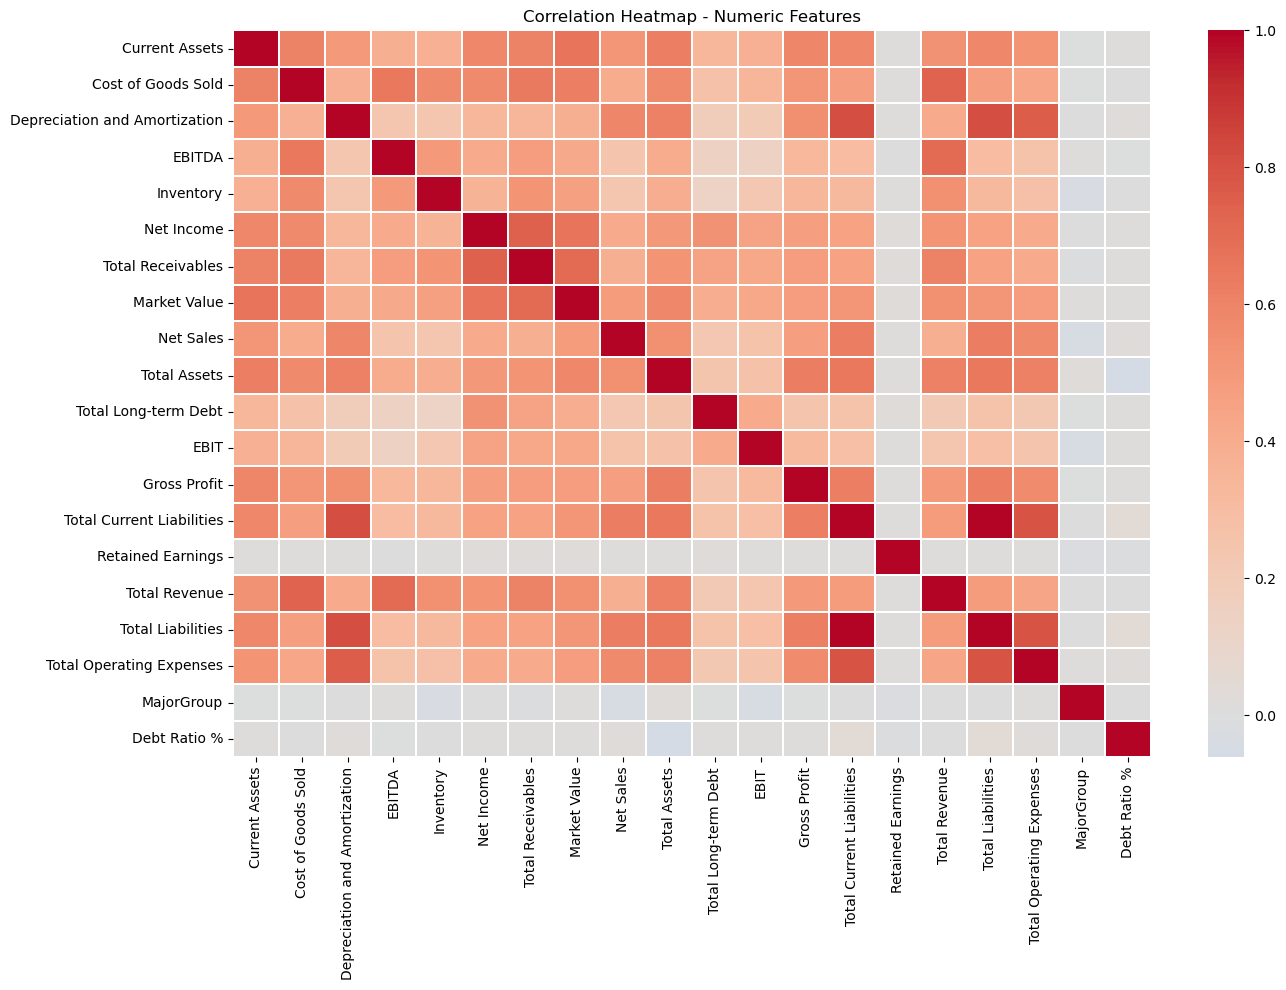

In [24]:
numeric_cols = df.select_dtypes(include=['number']).columns
numeric_df = df[numeric_cols].drop(columns=['Bankrupt'], errors='ignore')

corr = numeric_df.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.3)
plt.title("Correlation Heatmap - Numeric Features")
plt.tight_layout()
plt.show()

The correlation analysis reveals several strong positive relationships among the raw financial variables, particularly between size-related items (Total Assets, Total Liabilities, Total Revenue, Net Sales) and profitability measures (EBIT, EBITDA, Gross Profit, Net Income). Notable high correlations also exist between Total Revenue and Net Sales, as well as between EBIT and EBITDA. These patterns indicate significant multicollinearity driven by the absolute scale of the accounting figures.

This level of inter-feature correlation suggests that **tree-based models** (such as Random Forest, XGBoost, or LightGBM) would be more suitable than linear classifiers (e.g., Logistic Regression) for bankruptcy prediction. Tree-based algorithms are robust to multicollinearity and do not assume feature independence, whereas linear models may produce unstable coefficients and reduced interpretability in the presence of highly correlated predictors.

### 2.5 Split the data

In [38]:
target = "Bankrupt"
X = df.drop(columns=target)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)

X_train: (53504, 21)
X_test:  (13376, 21)


### 2.6 Resample to address class imbalance

In [39]:
# Under-sampling: reduce majority class to match minority
under_sampler = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = under_sampler.fit_resample(X_train, y_train)
print("Under-sampled training set:", X_train_under.shape)
print(y_train_under.value_counts())

Under-sampled training set: (7100, 21)
Bankrupt
0    3550
1    3550
Name: count, dtype: int64


In [40]:
# Over-sampling: duplicate minority class to match majority
over_sampler = RandomOverSampler(random_state=42)
X_train_over, y_train_over = over_sampler.fit_resample(X_train, y_train)
print("Over-sampled training set:", X_train_over.shape)
print(y_train_over.value_counts())

Over-sampled training set: (99908, 21)
Bankrupt
0    49954
1    49954
Name: count, dtype: int64


### 2.7 Baseline accuracy

In [41]:
acc_baseline = y_train.value_counts(normalize=True).max()
print(f"Baseline Accuracy: {acc_baseline:.4f}")
print("A model that always predicts 'not bankrupt' gets this score for free.")

Baseline Accuracy: 0.9336
A model that always predicts 'not bankrupt' gets this score for free.


### 2.8 Build three Decision Tree classifiers

In [44]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.base import clone

# Define features
numeric_features = X_train.select_dtypes(include=['number']).columns.tolist()
categorical_features = ['Division']

# Create preprocessor (fitted ONLY once on X_train)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='median'), numeric_features),
        ('cat', OneHotEncoder(
            handle_unknown='ignore',
            sparse_output=False,
            min_frequency=50,      # groups 'J' and any other rare ones
            max_categories=10      # safety limit
        ), categorical_features)
    ],
    remainder='drop'
)

# Fit preprocessor ONCE on the original training data
preprocessor.fit(X_train)

# Transform the resampled sets with the SAME preprocessor
X_train_under_trans = preprocessor.transform(X_train_under)
X_train_over_trans  = preprocessor.transform(X_train_over)

# Build models
# Regular model (uses full pipeline)
model_reg = make_pipeline(preprocessor, DecisionTreeClassifier(random_state=42))
model_reg.fit(X_train, y_train)

# Under- and Over-sampled models (use already-transformed data)
model_under = DecisionTreeClassifier(random_state=42)
model_under.fit(X_train_under_trans, y_train_under)

model_over = DecisionTreeClassifier(random_state=42)
model_over.fit(X_train_over_trans, y_train_over)

print("All models trained succesfully!")

All models trained succesfully!


### 2.9 Evaluate all three models

In [45]:
# Transform test set once with the same preprocessor
X_test_trans = preprocessor.transform(X_test)

print(f"{'Model':<15} {'Train Acc':>12} {'Test Acc':>12}")
print("-" * 42)

for name, model, Xtr, ytr in [
    ("Regular", model_reg, X_train, y_train),
    ("Under",   model_under, X_train_under_trans, y_train_under),
    ("Over",    model_over,  X_train_over_trans,  y_train_over)
]:
    train_acc = model.score(Xtr, ytr)
    test_acc  = model.score(X_test_trans, y_test) if name != "Regular" else model.score(X_test, y_test)
    print(f"{name:<15} {train_acc:>12.4f} {test_acc:>12.4f}")

Model              Train Acc     Test Acc
------------------------------------------
Regular               1.0000       0.8865
Under                 1.0000       0.6222
Over                  1.0000       0.8981


                  Regular Model
Confusion Matrix:
[[11664   831]
 [  687   194]]


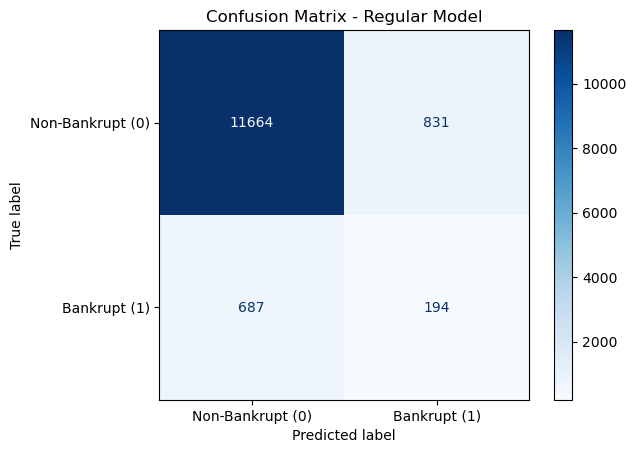


Classification Report:
              precision    recall  f1-score   support

           0     0.9444    0.9335    0.9389     12495
           1     0.1893    0.2202    0.2036       881

    accuracy                         0.8865     13376
   macro avg     0.5668    0.5768    0.5712     13376
weighted avg     0.8946    0.8865    0.8905     13376

Decision Tree Depth: 49


                  Under Model
Confusion Matrix:
[[7788 4707]
 [ 347  534]]


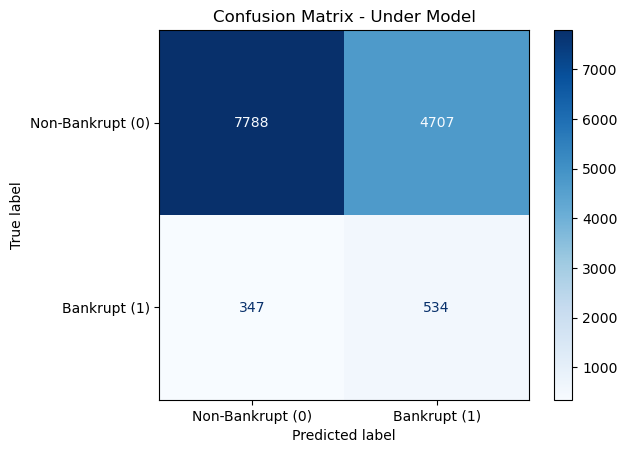


Classification Report:
              precision    recall  f1-score   support

           0     0.9573    0.6233    0.7550     12495
           1     0.1019    0.6061    0.1745       881

    accuracy                         0.6222     13376
   macro avg     0.5296    0.6147    0.4647     13376
weighted avg     0.9010    0.6222    0.7168     13376

Decision Tree Depth: 25


                  Over Model
Confusion Matrix:
[[11838   657]
 [  706   175]]


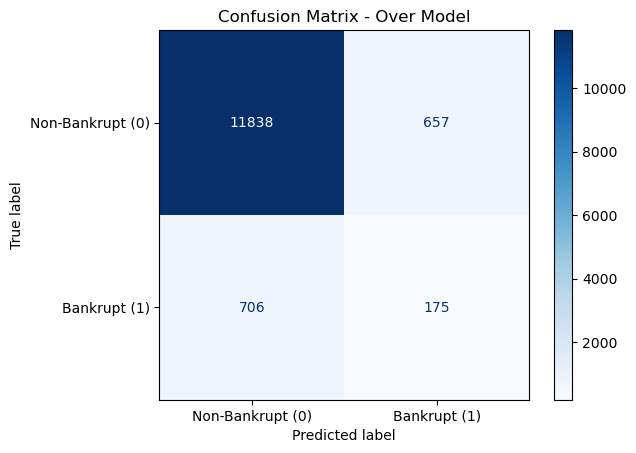


Classification Report:
              precision    recall  f1-score   support

           0     0.9437    0.9474    0.9456     12495
           1     0.2103    0.1986    0.2043       881

    accuracy                         0.8981     13376
   macro avg     0.5770    0.5730    0.5749     13376
weighted avg     0.8954    0.8981    0.8967     13376

Decision Tree Depth: 45




In [47]:
# We'll use the transformed test set from previous step
X_test_trans = preprocessor.transform(X_test)

models = {
    "Regular": (model_reg, X_train, y_train),
    "Under":   (model_under, X_train_under_trans, y_train_under),
    "Over":    (model_over,  X_train_over_trans,  y_train_over)
}

for name, (model, Xtr, ytr) in models.items():
    print("="*60)
    print(f"                  {name} Model")
    print("="*60)
    
    # Predictions
    if name == "Regular":
        y_pred = model.predict(X_test)
    else:
        y_pred = model.predict(X_test_trans)
    
    # Confusion Matrix
    print("Confusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Bankrupt (0)', 'Bankrupt (1)'])
    disp.plot(cmap='Blues')
    plt.title(f"Confusion Matrix - {name} Model")
    plt.show()
    
    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, digits=4))
    
    # Tree Depth
    if name == "Regular":
        depth = model.named_steps['decisiontreeclassifier'].get_depth()
    else:
        depth = model.get_depth()
    
    print(f"Decision Tree Depth: {depth}")
    print("\n")

All three Decision Tree models show severe overfitting (training accuracy = 1.0). The regular model achieves high test accuracy by mostly predicting the majority class, resulting in very low recall (0.22) for bankrupt companies. Undersampling improves minority class recall but drastically increases false positives. Oversampling yields the best overall accuracy but still delivers poor recall (0.20) on the bankrupt class. These results highlight the difficulty of modeling highly imbalanced data with a single decision tree and motivate the use of ensemble methods and better class-handling techniques.

### 2.10 Feature importance

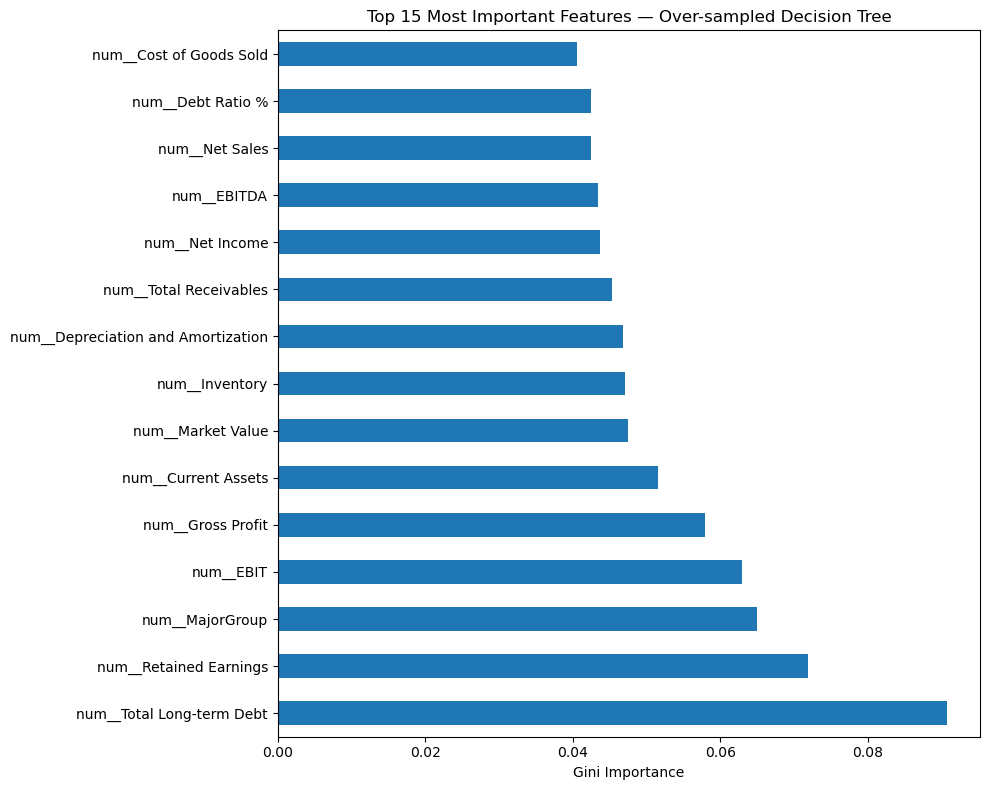

In [48]:
# For the over-sampled model
importances = model_over.feature_importances_
feature_names = preprocessor.get_feature_names_out()

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
feat_imp.head(15).plot(kind="barh")
plt.xlabel("Gini Importance")
plt.title("Top 15 Most Important Features — Over-sampled Decision Tree")
plt.tight_layout()
plt.show()

### 2.11 Save the model

In [49]:
with open("models/model-1.pkl", "wb") as f:
    pickle.dump(model_over, f)

# Verify it loads correctly
with open("models/model-1.pkl", "rb") as f:
    loaded = pickle.load(f)
print("Model loaded successfully:", loaded)

Model loaded successfully: DecisionTreeClassifier(random_state=42)


---
> The U.S. bankruptcy dataset is highly imbalanced, with approximately 93.4% non-bankrupt companies in the test set. As expected, a single Decision Tree trained on the original data achieves high accuracy (88.65%) but very low recall for the bankrupt class (0.22). Undersampling improves recall for bankruptcies (0.61) at the expense of many false positives, while oversampling gives the highest accuracy (89.81%) but still poor minority-class recall (0.20). All models suffer from severe overfitting, as indicated by perfect training accuracy and deep trees (depth 25–49). These results demonstrate the limitations of using a single decision tree on imbalanced financial data and justify exploring ensemble methods in the next step.

## 3: Ensemble Models - Random Forest with GridSearchCV

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score

In [5]:
def wrangle(filepath):
    with gzip.open(filepath, "r") as f:
        data = json.load(f)
    df = pd.DataFrame.from_dict(data["data"]).set_index("company_id")
    return df


df = wrangle("data/us-bankruptcy-data.json.gz")

target = "Bankrupt"
X = df.drop(columns=target)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

over_sampler = RandomOverSampler(random_state=42)
X_train_over, y_train_over = over_sampler.fit_resample(X_train, y_train)

acc_baseline = y_train.value_counts(normalize=True).max()
print(f"Baseline Accuracy: {acc_baseline:.4f}")
print("X_train_over shape:", X_train_over.shape)

Baseline Accuracy: 0.9336
X_train_over shape: (99908, 20)


### 3.1 Build the Random Forest pipeline

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.base import clone

# ------------------- Define features -------------------
numeric_features = X_train.select_dtypes(include=['number']).columns.tolist()
categorical_features = ['Division']

# ------------------- Create ONE shared preprocessor -------------------
preprocessor = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='median'), numeric_features),
        ('cat', OneHotEncoder(
            handle_unknown='ignore',
            sparse_output=False,
            min_frequency=50,      # groups very rare categories like 'J'
            max_categories=10
        ), categorical_features)
    ],
    remainder='drop'
)

# ------------------- Build the full pipeline -------------------
clf = make_pipeline(
    preprocessor,
    RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        class_weight=None          # we'll rely on oversampling for now
    )
)

print(clf)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  SimpleImputer(strategy='median'),
                                                  ['X1', 'X2', 'X3', 'X4', 'X5',
                                                   'X6', 'X7', 'X8', 'X9',
                                                   'X10', 'X11', 'X12', 'X13',
                                                   'X14', 'X15', 'X16', 'X17',
                                                   'X18', 'MajorGroup']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                max_categories=10,
                                                                min_frequency=50,
                                                                sparse_output=False),
                                    

### 3.2 Quick cross-validation before tuning

In [8]:
cv_scores = cross_val_score(
    clf, 
    X_train_over, 
    y_train_over, 
    cv=5, 
    n_jobs=-1,
    scoring='accuracy'
)

print("CV accuracy scores:", cv_scores.round(4))
print(f"Mean CV accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

CV accuracy scores: [0.9985 0.9987 0.9989 0.9985 0.9986]
Mean CV accuracy: 0.9987 ± 0.0002


### 3.3 Hyperparameter grid

In [9]:
param_grid = {
    'randomforestclassifier__n_estimators': [100, 200],
    'randomforestclassifier__max_depth': [None, 25],
    'randomforestclassifier__min_samples_leaf': [1, 2],
    'randomforestclassifier__max_features': ['sqrt', 0.8]
}
param_grid

{'randomforestclassifier__n_estimators': [100, 200],
 'randomforestclassifier__max_depth': [None, 25],
 'randomforestclassifier__min_samples_leaf': [1, 2],
 'randomforestclassifier__max_features': ['sqrt', 0.8]}

### 3.4 GridSearchCV

In [10]:
model_rf = GridSearchCV(
    clf,
    param_grid,
    cv=3,
    n_jobs=-1,
    scoring='f1',           # Better than accuracy for imbalanced data
    verbose=2
)

model_rf.fit(X_train_over, y_train_over)

Fitting 3 folds for each of 16 candidates, totalling 48 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'randomforestclassifier__max_depth': [None, 25], 'randomforestclassifier__max_features': ['sqrt', 0.8], 'randomforestclassifier__min_samples_leaf': [1, 2], 'randomforestclassifier__n_estimators': [100, 200]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [11]:
print("Best hyperparameters:")
model_rf.best_params_

Best hyperparameters:


{'randomforestclassifier__max_depth': None,
 'randomforestclassifier__max_features': 'sqrt',
 'randomforestclassifier__min_samples_leaf': 1,
 'randomforestclassifier__n_estimators': 200}

### 3.5 Evaluate the best Random Forest

Training Accuracy (on oversampled data): 1.0
Test Accuracy: 0.9367523923444976

Classification Report:
              precision    recall  f1-score   support

           0     0.9380    0.9983    0.9672     12495
           1     0.7273    0.0636    0.1169       881

    accuracy                         0.9368     13376
   macro avg     0.8326    0.5309    0.5421     13376
weighted avg     0.9241    0.9368    0.9112     13376



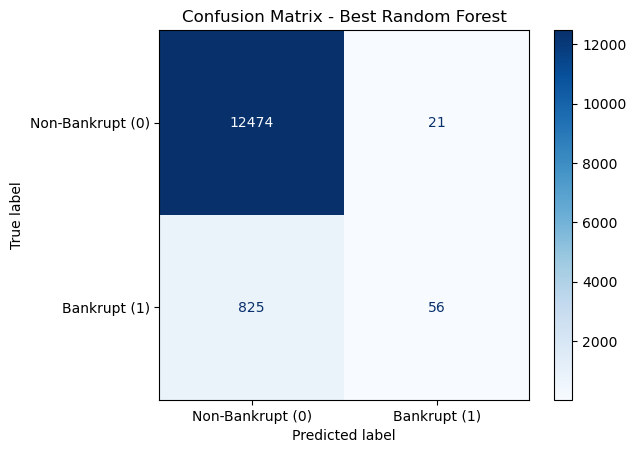

In [16]:
# Best model from GridSearchCV
best_rf = model_rf.best_estimator_

# Predictions on test set (pipeline automatically handles imputation + OneHotEncoder)
y_pred = best_rf.predict(X_test)

print("Training Accuracy (on oversampled data):", best_rf.score(X_train_over, y_train_over))
print("Test Accuracy:", best_rf.score(X_test, y_test))
print("\n" + "="*60)

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("Classification Report:")
print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                              display_labels=['Non-Bankrupt (0)', 'Bankrupt (1)'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Best Random Forest")
plt.show()

The tuned Random Forest achieves a high test accuracy of 93.68%, but this is misleading due to severe class imbalance. It correctly identifies almost all non-bankrupt companies (recall = 0.9983) while detecting only 6.36% of actual bankrupt cases (recall = 0.0636). The model remains heavily biased toward the majority class despite oversampling. These results confirm that a standard Random Forest (even after hyperparameter tuning) is insufficient for this highly imbalanced dataset and motivate moving to techniques that better handle class imbalance.

### 3.6 Feature importance

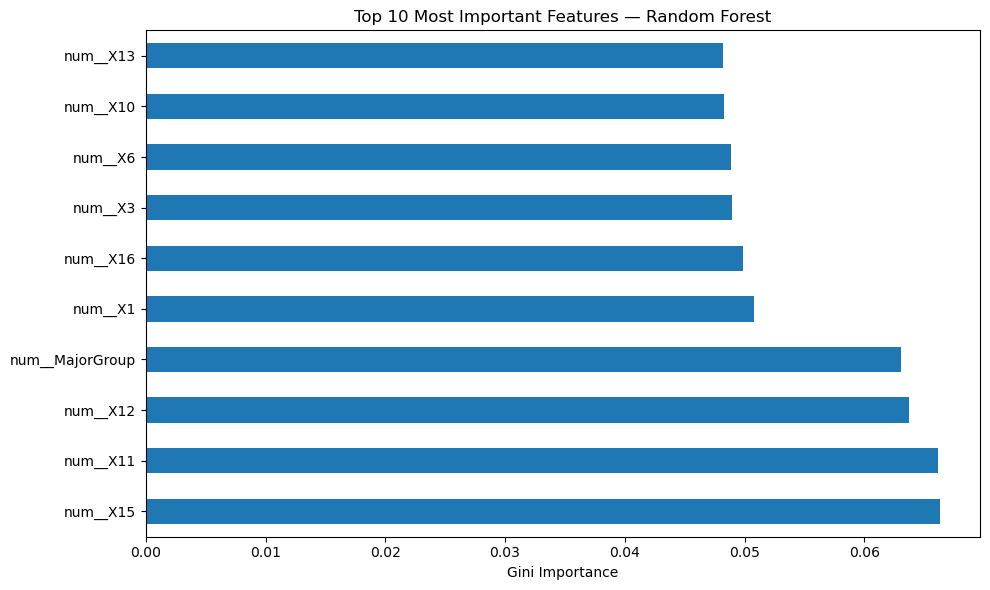

In [17]:
feature_names = model_rf.best_estimator_.named_steps['columntransformer'].get_feature_names_out()

importances = model_rf.best_estimator_.named_steps[
    "randomforestclassifier"
].feature_importances_

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# Plot top 10
plt.figure(figsize=(10, 6))
feat_imp.head(10).plot(kind="barh")
plt.xlabel("Gini Importance")
plt.title("Top 10 Most Important Features — Random Forest")
plt.tight_layout()
plt.show()

### 3.7 Build the make_predictions function and save

In [18]:
with open("models/model-2.pkl", "wb") as f:
    pickle.dump(model_rf, f)
print("Random Forest model saved.")

Random Forest model saved.


In [19]:
def make_predictions(data_filepath, model_filepath):
    """Load data and a pre-trained model, return bankruptcy predictions as a Series."""
    X_new = wrangle(data_filepath)
    
    with open(model_filepath, "rb") as f:
        model = pickle.load(f)

    print(f"Loaded model from {model_filepath}")
    print(f"Input shape: {X_new.shape}")
    
    y_pred = model.predict(X_new)
    
    return pd.Series(y_pred, index=X_new.index, name="Bankrupt")


# Test it on the test-features file (no labels)
y_test_pred = make_predictions(
    data_filepath="data/us-bankruptcy-data-test-features.json.gz",
    model_filepath="models/model-2.pkl",
)
print("Predictions shape:", y_test_pred.shape)
y_test_pred.head()

Loaded model from models/model-2.pkl
Input shape: (11802, 20)
Predictions shape: (11802,)


company_id
5     0
12    0
13    0
23    0
25    0
Name: Bankrupt, dtype: int64

---
> A Random Forest is an ensemble of decision trees, each trained on a random subset of the data and a random subset of features. By averaging the predictions of many trees, it reduces the high variance and overfitting observed in our single deep Decision Tree.
We built the model using a consistent preprocessing pipeline (median imputation for numeric features and one-hot encoding for the categorical Division column) applied to the oversampled training set. GridSearchCV was used to tune the key hyperparameters (n_estimators, max_depth, min_samples_leaf, and max_features) with 3-fold cross-validation and F1 scoring as the optimization metric.
The final tuned Random Forest achieved a test accuracy of 93.68%. However, it remains strongly biased toward the majority class, correctly identifying nearly all non-bankrupt companies (recall = 0.9983) while detecting only 6.36% of actual bankrupt cases (recall = 0.0636). This confirms that even a well-tuned Random Forest struggles with the severe class imbalance in this dataset.
The make_predictions() function successfully wraps the entire workflow into production-ready code: given any new dataset in the same format, it loads the saved model and returns bankruptcy predictions in seconds.

## 4: Gradient Boosting - Precision, Recall, and the Business Trade-off

In [ ]:
import ipywidgets as widgets
from ipywidgets import interact
from sklearn.ensemble import GradientBoostingClassifier

In [ ]:
def wrangle(filepath):
    with gzip.open(filepath, "r") as f:
        data = json.load(f)
    df = pd.DataFrame.from_dict(data["data"]).set_index("company_id")
    return df


df = wrangle("data/us-bankruptcy-data.json.gz")

target = "Bankrupt"
X = df.drop(columns=target)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

over_sampler = RandomOverSampler(random_state=42)
X_train_over, y_train_over = over_sampler.fit_resample(X_train, y_train)

acc_baseline = y_train.value_counts(normalize=True).max()
print(f"Baseline Accuracy: {acc_baseline:.4f}")

### 4.1 Build the Gradient Boosting pipeline

Unlike a Random Forest (which trains trees **in parallel** on random subsets), Gradient Boosting trains trees **sequentially** - each tree corrects the errors of the previous one. This makes it slower but often more accurate.

In [ ]:
clf_gb = make_pipeline(
    SimpleImputer(),
    GradientBoostingClassifier(random_state=42)
)
print(clf_gb)

### 4.2 Hyperparameter grid and GridSearchCV

In [ ]:
params_gb = {
    "simpleimputer__strategy": ["mean", "median"],
    "gradientboostingclassifier__max_depth": range(2, 5),
    "gradientboostingclassifier__n_estimators": range(20, 31, 5),
}
params_gb

In [ ]:
model_gb = GridSearchCV(
    clf_gb,
    param_grid=params_gb,
    cv=5,
    n_jobs=-1,
    verbose=1
)
model_gb.fit(X_train_over, y_train_over)

In [ ]:
print("Best hyperparameters:")
model_gb.best_params_

In [ ]:
# Top 10 cv results by rank
results = pd.DataFrame(model_gb.cv_results_)
results.sort_values("rank_test_score")[["params", "mean_test_score", "rank_test_score"]].head(10)

### 4.3 Accuracy scores

In [ ]:
acc_train = model_gb.score(X_train, y_train)
acc_test  = model_gb.score(X_test, y_test)
print(f"Training Accuracy: {acc_train:.4f}")
print(f"Test Accuracy:     {acc_test:.4f}")

### 4.4 Confusion matrix

In [ ]:
ConfusionMatrixDisplay.from_estimator(model_gb, X_test, y_test)
plt.title("Confusion Matrix — Gradient Boosting (best estimator)")
plt.tight_layout()
plt.show()

### 4.5 Classification report - precision and recall

In [ ]:
print(classification_report(y_test, model_gb.predict(X_test)))

**Reading the report:**
- **Precision (bankrupt class):** Of all companies the model flagged as bankrupt, what fraction truly went bankrupt?
- **Recall (bankrupt class):** Of all companies that actually went bankrupt, what fraction did the model catch?

There is an inherent tension between these two: increasing recall (catch more bankruptcies) usually increases false positives and lowers precision.

### 4.6 Business scenario 1 - Regulatory recall priority

Imagine a U.S. financial regulator sending early-warning notices to potentially distressed companies. Sending an unnecessary notice costs **\$200** in admin. A company that files for bankruptcy without prior warning costs the court system **\$40,000**.

Here, **recall** is the priority - we want to catch as many real bankruptcies as possible.

In [ ]:
def make_cnf_matrix_regulator(threshold):
    y_pred_proba = model_gb.predict_proba(X_test)[:, -1]
    y_pred = (y_pred_proba > threshold).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    admin_cost  = fp * 200
    court_cost  = fn * 40_000
    print(f"Threshold:        {threshold:.2f}")
    print(f"True Positives:   {tp}  (bankruptcies caught)")
    print(f"False Negatives:  {fn}  (bankruptcies missed)")
    print(f"Admin waste:      ${admin_cost:,}")
    print(f"Court costs:      ${court_cost:,}")
    print(f"Total cost:       ${admin_cost + court_cost:,}")
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, colorbar=False)
    plt.title(f"Regulator Model — threshold={threshold:.2f}")
    plt.tight_layout()
    plt.show()


thresh_widget = widgets.FloatSlider(min=0.0, max=1.0, value=0.5, step=0.05)
interact(make_cnf_matrix_regulator, threshold=thresh_widget);

### 4.7 Business scenario 2 — Private equity precision priority

A private equity firm buys distressed companies to restructure and resell. Correctly identifying a bankrupt company yields **\$80M** profit. Buying a company that doesn't go bankrupt costs **\$200M** in losses.

Here, **precision** is the priority — only flag companies when you're confident.

In [ ]:
def make_cnf_matrix_pe(threshold):
    y_pred_proba = model_gb.predict_proba(X_test)[:, -1]
    y_pred = (y_pred_proba > threshold).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    profit = tp * 80_000_000
    losses = fp * 200_000_000
    print(f"Threshold:        {threshold:.2f}")
    print(f"True Positives:   {tp}  (profitable acquisitions)")
    print(f"False Positives:  {fp}  (bad bets)")
    print(f"Profit:           ${profit:,}")
    print(f"Losses:           ${losses:,}")
    print(f"Net P&L:          ${profit - losses:,}")
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, colorbar=False)
    plt.title(f"PE Firm Model — threshold={threshold:.2f}")
    plt.tight_layout()
    plt.show()


thresh_widget_pe = widgets.FloatSlider(min=0.0, max=1.0, value=0.5, step=0.05)
interact(make_cnf_matrix_pe, threshold=thresh_widget_pe);

### 4.8 Save the Gradient Boosting model

In [ ]:
with open("models/model-3.pkl", "wb") as f:
    pickle.dump(model_gb, f)
print("Gradient Boosting model saved to models/model-3.pkl")

### 4.9 Build and save the reusable prediction module

In [ ]:
%%writefile my_predictor.py
"""Reusable module for U.S. bankruptcy prediction."""
import gzip
import json
import pickle

import pandas as pd


def wrangle(filepath):
    """Load a gzip-compressed JSON file into a tidy DataFrame."""
    with gzip.open(filepath, "r") as f:
        data = json.load(f)
    df = pd.DataFrame.from_dict(data["data"]).set_index("company_id")
    return df


def make_predictions(data_filepath, model_filepath):
    """Generate bankruptcy predictions for new data using a saved model.

    Parameters
    ----------
    data_filepath  : str  Path to a .json.gz file of company financial features.
    model_filepath : str  Path to a .pkl file of a trained sklearn pipeline.

    Returns
    -------
    pd.Series  Bankruptcy predictions indexed by company_id.
    """
    X_new = wrangle(data_filepath)
    with open(model_filepath, "rb") as f:
        model = pickle.load(f)
    y_pred = model.predict(X_new)
    return pd.Series(y_pred, index=X_new.index, name="Bankrupt")

In [ ]:
from my_predictor import make_predictions

y_test_pred = make_predictions(
    data_filepath="data/us-bankruptcy-data-test-features.json.gz",
    model_filepath="models/model-3.pkl",
)
print("Predictions shape:", y_test_pred.shape)
print("Sample predictions:")
y_test_pred.head()

---
> Gradient Boosting builds on Random Forest by learning sequentially — each new tree is trained on the residual errors of all previous trees rather than a random subset. This makes it more sensitive to subtle patterns in the minority class, which helps with bankruptcy detection. The business scenario widgets make a critical real-world point: there is no universally 'correct' threshold. For the regulator, a low threshold (say 0.2) catches more bankruptcies at the cost of false alarms — the total court cost savings dwarf the admin waste. For the private equity firm, a high threshold (say 0.7) ensures that every flagged company is a strong bet, even if some bankruptcies are missed. The `my_predictor.py` module is our first step toward a deployable product: a standalone script with clean interfaces that could be scheduled to run every quarter on new financial data.